In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install librosa soundfile audiomentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 19.6 MB/s eta 0:00:00
  Attempting uninstall: soxr
    Found existing installation: soxr 1.0.0
    Uninstalling soxr-1.0.0:
      Successfully uninstalled soxr-1.0.0


In [ ]:
import os
import glob
import librosa
import librosa.display
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
import audiomentations as A
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound/West China Second University Hospital"

pneumonia_path = os.path.join(DATASET_PATH, 'pneumonia')
normal_path = os.path.join(DATASET_PATH, 'normal')

In [ ]:
# Get all MP3 files
pneumonia_files = glob.glob(os.path.join(pneumonia_path, '*.mp3'))
normal_files = glob.glob(os.path.join(normal_path, '*.mp3'))

print(f"Pneumonia samples: {len(pneumonia_files)}")
print(f"Normal samples: {len(normal_files)}")
print(f"Total samples: {len(pneumonia_files) + len(normal_files)}")

Pneumonia samples: 82
Normal samples: 91
Total samples: 173


In [ ]:
def analyze_audio_file(file_path):
    """Extract metadata from audio file"""
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)

        # Basic statistics
        return {
            'file': os.path.basename(file_path),
            'sample_rate': sr,
            'duration': duration,
            'samples': len(y),
            'max_amplitude': np.max(np.abs(y)),
            'mean_amplitude': np.mean(np.abs(y)),
            'rms_energy': np.sqrt(np.mean(y**2))
        }
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [ ]:
all_files = pneumonia_files + normal_files
labels = ['pneumonia'] * len(pneumonia_files) + ['normal'] * len(normal_files)

In [ ]:
# Analyze all files
print("\nAnalyzing audio files...")
metadata = []
for file, label in zip(all_files, labels):
    info = analyze_audio_file(file)
    if info:
        info['label'] = label
        info['filepath'] = file
        metadata.append(info)

# Create DataFrame
df_metadata = pd.DataFrame(metadata)


Analyzing audio files...


In [ ]:
print(f"\nDataset summary:")
print(f"  Duration range: {df_metadata['duration'].min():.2f}s - {df_metadata['duration'].max():.2f}s")
print(f"  Mean duration: {df_metadata['duration'].mean():.2f}s")


Dataset summary:
  Duration range: 0.20s - 42.58s
  Mean duration: 3.95s



SAMPLE VISUALIZATIONS

Pneumonia Sample:


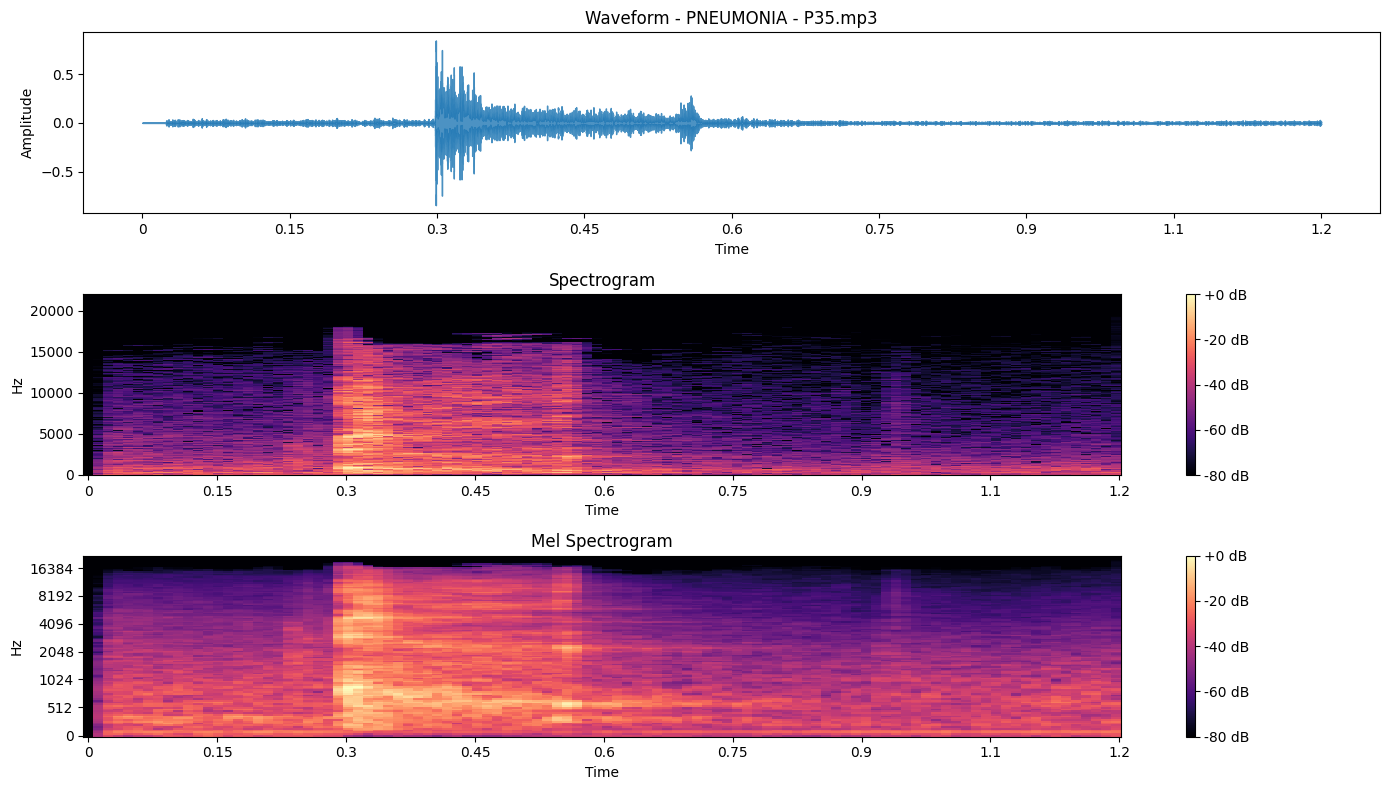


Normal Sample:


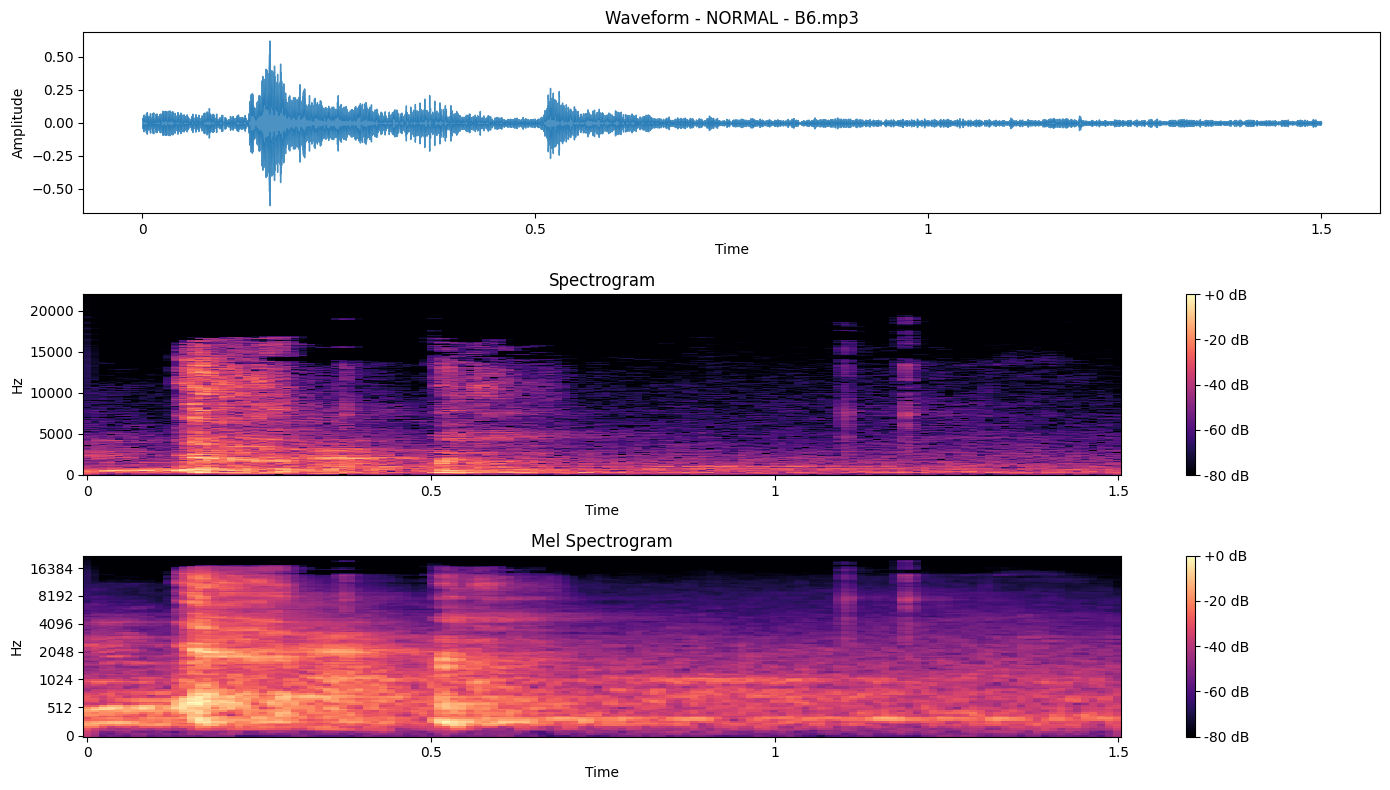

In [ ]:
def visualize_audio(file_path, label):
    """Visualize waveform and spectrogram"""
    y, sr = librosa.load(file_path, sr=None)

    plt.figure(figsize=(14, 8))

    # Waveform
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.8)
    plt.title(f'Waveform - {label.upper()} - {os.path.basename(file_path)}')
    plt.ylabel('Amplitude')

    # Spectrogram
    plt.subplot(3, 1, 2)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram')

    # Mel Spectrogram
    plt.subplot(3, 1, 3)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')

    plt.tight_layout()
    plt.show()

# Visualize sample files from each class
print("\n" + "="*60)
print("SAMPLE VISUALIZATIONS")
print("="*60)

if len(pneumonia_files) > 0:
    print("\nPneumonia Sample:")
    visualize_audio(pneumonia_files[0], 'Pneumonia')

if len(normal_files) > 0:
    print("\nNormal Sample:")
    visualize_audio(normal_files[0], 'Normal')

###PATIENT-LEVEL TRAIN/VAL/TEST SPLIT

Split by patient BEFORE segmentation to avoid data leakage

In [ ]:
# Create patient IDs (each file = one patient)
df_metadata['patient_id'] = df_metadata['file']

# Get unique patients and their labels
patients = df_metadata['file'].values
patient_labels = (df_metadata['label'] == 'pneumonia').astype(int).values

# Split patients into train/val/test (70/15/15)
patients_train, patients_temp, labels_train, labels_temp = train_test_split(
    patients, patient_labels, test_size=0.3, random_state=42, stratify=patient_labels
)

patients_val, patients_test, labels_val, labels_test = train_test_split(
    patients_temp, labels_temp, test_size=0.5, random_state=42, stratify=labels_temp
)

print(f"\nPatient split:")
print(f"Train patients: {len(patients_train)} (Pneumonia={np.sum(labels_train==1)}, Normal={np.sum(labels_train==0)})")
print(f"Val patients: {len(patients_val)} (Pneumonia={np.sum(labels_val==1)}, Normal={np.sum(labels_val==0)})")
print(f"Test patients: {len(patients_test)} (Pneumonia={np.sum(labels_test==1)}, Normal={np.sum(labels_test==0)})")

# Create split dictionaries
train_patients = set(patients_train)
val_patients = set(patients_val)
test_patients = set(patients_test)


Patient split:
Train patients: 121 (Pneumonia=57, Normal=64)
Val patients: 26 (Pneumonia=12, Normal=14)
Test patients: 26 (Pneumonia=13, Normal=13)


PREPROCESSING PIPELINE

In [ ]:
# Configuration
TARGET_SR = 16000
SEGMENT_DURATION = 1.0
OVERLAP = 0.5

In [ ]:
def remove_silence(y, sr, top_db=20):
    """Remove silence using Voice Activity Detection"""
    intervals = librosa.effects.split(y, top_db=top_db)
    if len(intervals) == 0:
        return y
    y_trimmed = np.concatenate([y[start:end] for start, end in intervals])
    return y_trimmed

def high_pass_filter(y, sr, cutoff=80):
    """Apply high-pass filter to remove low-frequency noise"""
    if len(y) < int(sr * 0.1): # Skip if audio too short
        return y
    nyquist = sr / 2
    normal_cutoff = cutoff / nyquist
    b, a = butter(5, normal_cutoff, btype='high', analog=False)
    y_filtered = filtfilt(b, a, y)
    return y_filtered

def normalize_audio(y):
    """Normalize audio amplitude to [-1, 1]"""
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y_normalized = y / max_val
    else:
        y_normalized = y
    return y_normalized.astype(np.float32)

def segment_audio(y, sr, segment_duration=1.0, overlap=0.5):
    """Segment audio into fixed-length chunks with overlap"""
    segment_length = int(segment_duration * sr)
    hop_length = int((segment_duration - overlap) * sr)

    segments = []

    # Case 1: Audio shorter than one segment -> PAD
    if len(y) < segment_length:
        pad_width = segment_length - len(y)
        y_padded = np.pad(y, (0, pad_width), mode='constant')
        segments.append(y_padded)
        return segments

    # Case 2: Normal segmentation with overlap
    for start in range(0, len(y) - segment_length + 1, hop_length):
        segment = y[start:start + segment_length]
        segments.append(segment)

    return segments

In [ ]:
def preprocess_audio(file_path, target_sr=16000):
    """
    Complete preprocessing pipeline for single file

    Steps:
    1. Load and resample
    2. Remove silence (VAD)
    3. Apply high-pass filter
    """
    # 1. Load and resample
    y, sr = librosa.load(file_path, sr=target_sr)

    # 2. Remove silence
    y = remove_silence(y, sr, top_db=20)

    # 3. Apply high-pass filter
    y = high_pass_filter(y, sr, cutoff=80)

    return y, sr

PREPROCESS ALL FILES

In [ ]:
preprocessed_patients = {}

for _, row in tqdm(df_metadata.iterrows(), total=len(df_metadata), desc="Preprocessing"):
    file_path = row['filepath']
    patient_id = row['file']
    label = row['label']

    # Preprocess audio (no segmentation)
    y_preprocessed, sr = preprocess_audio(file_path, TARGET_SR)

    preprocessed_patients[patient_id] = {
        'audio': y_preprocessed,
        'label': label,
        'sample_rate': sr
    }

print(f"\nPreprocessed {len(preprocessed_patients)} patients")

Preprocessing: 100%|██████████| 173/173 [00:05<00:00, 33.31it/s]


Preprocessed 173 patients


SEGMENT EACH SPLIT SEPARATELY

In [ ]:
def segment_and_normalize_patients(patient_list, preprocessed_dict):
    """
    Segment patients and normalize each segment individually
    """
    segments = []
    segment_labels = []

    for patient_id in patient_list:
        patient_data = preprocessed_dict[patient_id]
        y = patient_data['audio']
        label = patient_data['label']
        sr = patient_data['sample_rate']

        # Segment the preprocessed audio
        patient_segments = segment_audio(y, sr, SEGMENT_DURATION, OVERLAP)

        # Normalize each segment individually
        for seg in patient_segments:
            seg_normalized = normalize_audio(seg)
            segments.append(seg_normalized)
            segment_labels.append(1 if label == 'pneumonia' else 0)

    return np.array(segments), np.array(segment_labels)

# Segment training patients
X_train, y_train = segment_and_normalize_patients(train_patients, preprocessed_patients)

# Segment validation patients
X_val, y_val = segment_and_normalize_patients(val_patients, preprocessed_patients)

# Segment test patients
X_test, y_test = segment_and_normalize_patients(test_patients, preprocessed_patients)

print(f"\nSegmentation results:")
print(f"  Training segments: {len(X_train)}")
print(f"  Validation segments: {len(X_val)}")
print(f"  Test segments: {len(X_test)}")


Segmentation results:
  Training segments: 439
  Validation segments: 83
  Test segments: 77


AUDIO AUGMENTATION (TRAINING ONLY)

In [ ]:
# Define augmentation pipeline
augment = A.Compose([
    A.PitchShift(min_semitones=-2, max_semitones=2, p=0.5),
    A.TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
    A.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.3),
    A.Gain(min_gain_db=-6, max_gain_db=6, p=0.3)
])

def augment_segment(audio, sr, n_augmentations=3):
    """Generate augmented versions of audio segment"""
    augmented = []
    for _ in range(n_augmentations):
        aug_audio = augment(samples=audio, sample_rate=sr)
        augmented.append(aug_audio)
    return augmented

# Augment training set only
X_train_augmented = []
y_train_augmented = []

for audio, label in tqdm(zip(X_train, y_train), total=len(X_train), desc="Augmenting"):
    # Add original
    X_train_augmented.append(audio)
    y_train_augmented.append(label)

    # Add augmented versions
    aug_segments = augment_segment(audio, TARGET_SR, n_augmentations=3)
    for aug_audio in aug_segments:
        X_train_augmented.append(aug_audio)
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

print(f"\nAugmentation results:")
print(f"  Training (original): {len(X_train)} segments")
print(f"  Training (augmented): {len(X_train_augmented)} segments")
print(f"  Augmentation factor: {len(X_train_augmented) / len(X_train):.1f}x")

Augmenting: 100%|██████████| 439/439 [00:08<00:00, 50.60it/s]


Augmentation results:
  Training (original): 439 segments
  Training (augmented): 1756 segments
  Augmentation factor: 4.0x


In [ ]:
OUTPUT_BASE = "/content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound"

In [ ]:
# Create output directories
SPLIT_DIR = os.path.join(OUTPUT_BASE, 'data_splits')
os.makedirs(SPLIT_DIR, exist_ok=True)

# Save training set (both original and augmented)
np.save(os.path.join(SPLIT_DIR, 'X_train_original.npy'), X_train)
np.save(os.path.join(SPLIT_DIR, 'y_train_original.npy'), y_train)
np.save(os.path.join(SPLIT_DIR, 'X_train_augmented.npy'), X_train_augmented)
np.save(os.path.join(SPLIT_DIR, 'y_train_augmented.npy'), y_train_augmented)

# Save validation set
np.save(os.path.join(SPLIT_DIR, 'X_val.npy'), X_val)
np.save(os.path.join(SPLIT_DIR, 'y_val.npy'), y_val)

# Save test set
np.save(os.path.join(SPLIT_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(SPLIT_DIR, 'y_test.npy'), y_test)

# Save patient split information
split_info = {
    'train_patients': list(train_patients),
    'val_patients': list(val_patients),
    'test_patients': list(test_patients),
    'config': {
        'target_sr': TARGET_SR,
        'segment_duration': SEGMENT_DURATION,
        'overlap': OVERLAP
    }
}

with open(os.path.join(SPLIT_DIR, 'patient_split_info.pkl'), 'wb') as f:
    pickle.dump(split_info, f)

print(f" All data saved to: {SPLIT_DIR}")

 All data saved to: /content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound/data_splits_corrected


Visualizing Pneumonia Sample...


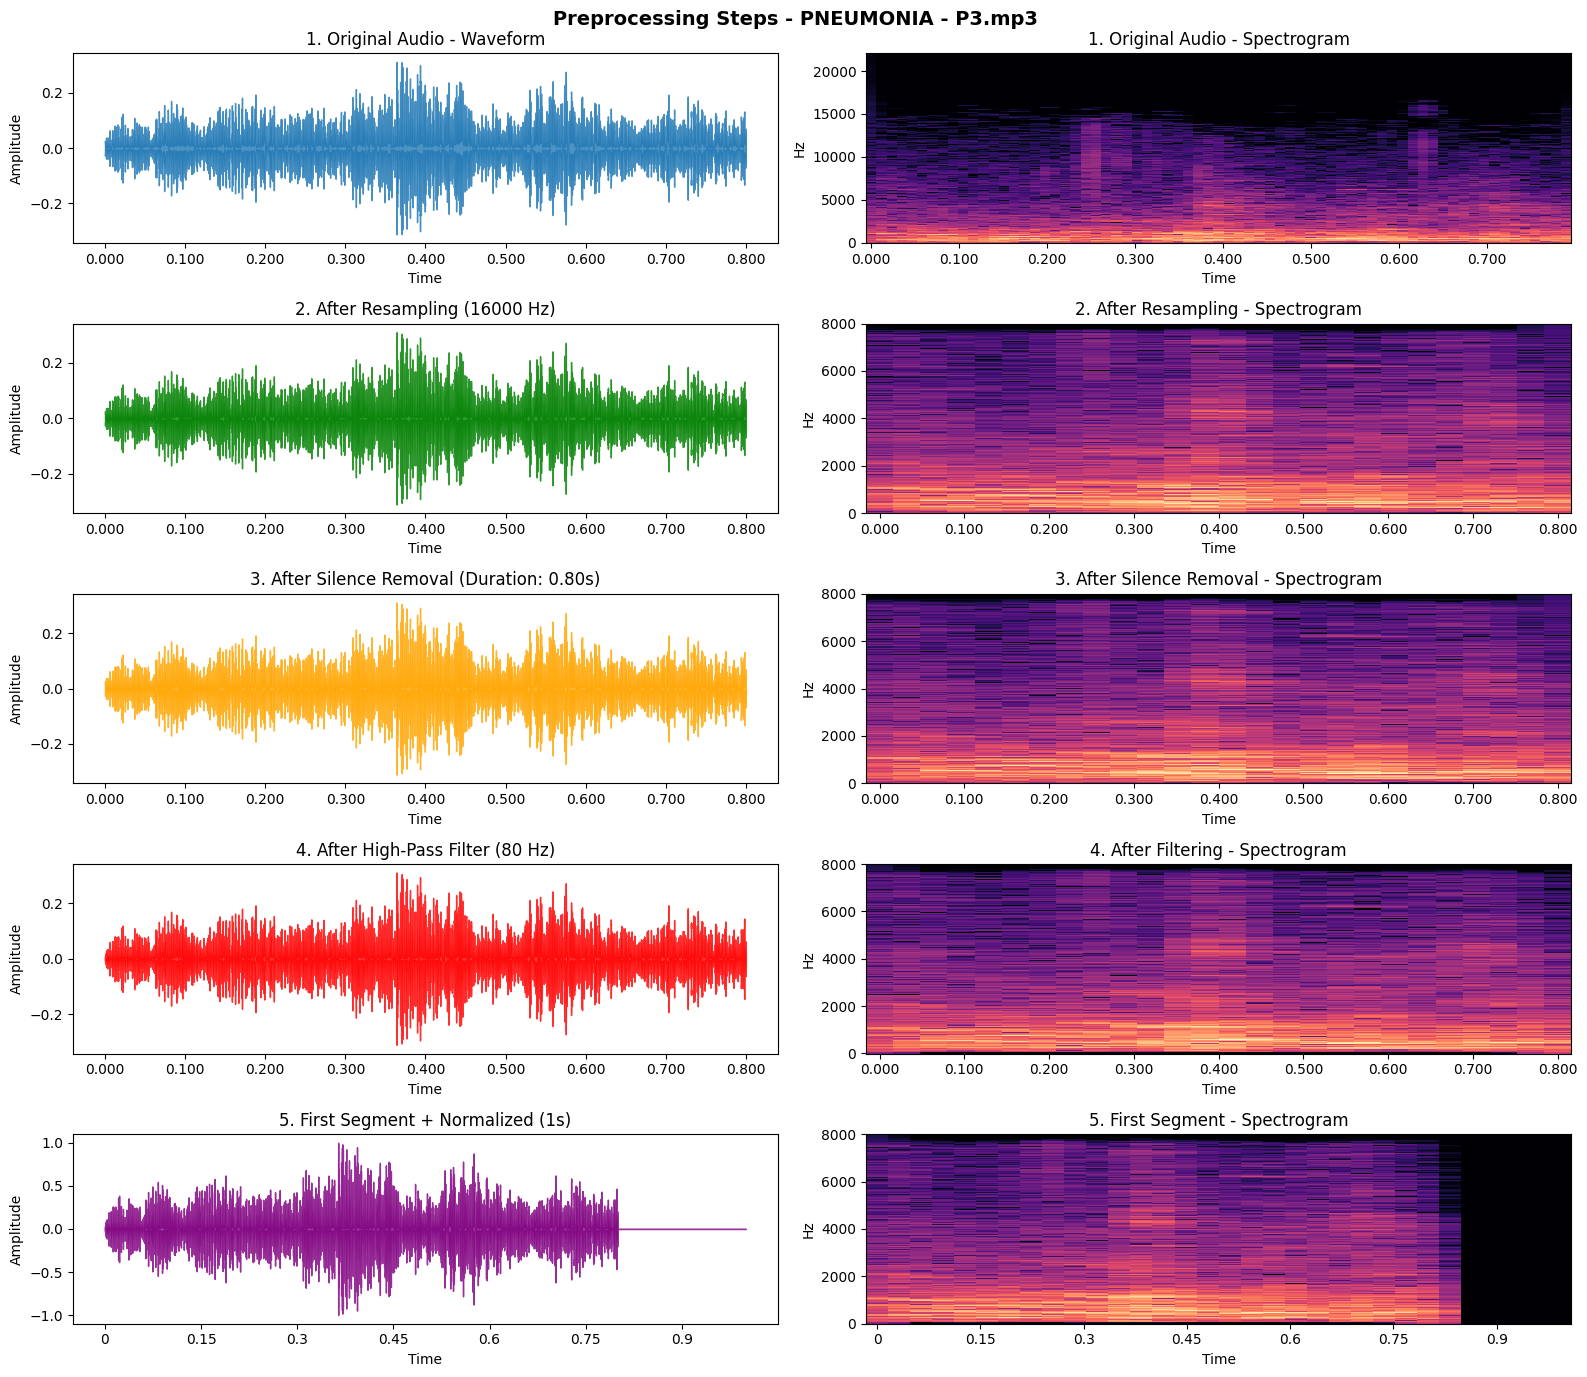


PREPROCESSING STATISTICS - PNEUMONIA
Original duration: 0.80s
After silence removal: 0.80s (reduced by 0.0%)
Number of segments created: 1
Segment duration: 1.00s
First segment normalized range: [-1.000, 0.945]

Amplitude statistics:
  Original max: 0.3114
  Filtered (before norm) max: 0.3105
  First segment (after norm) max: 1.0000


Visualizing Normal Sample...


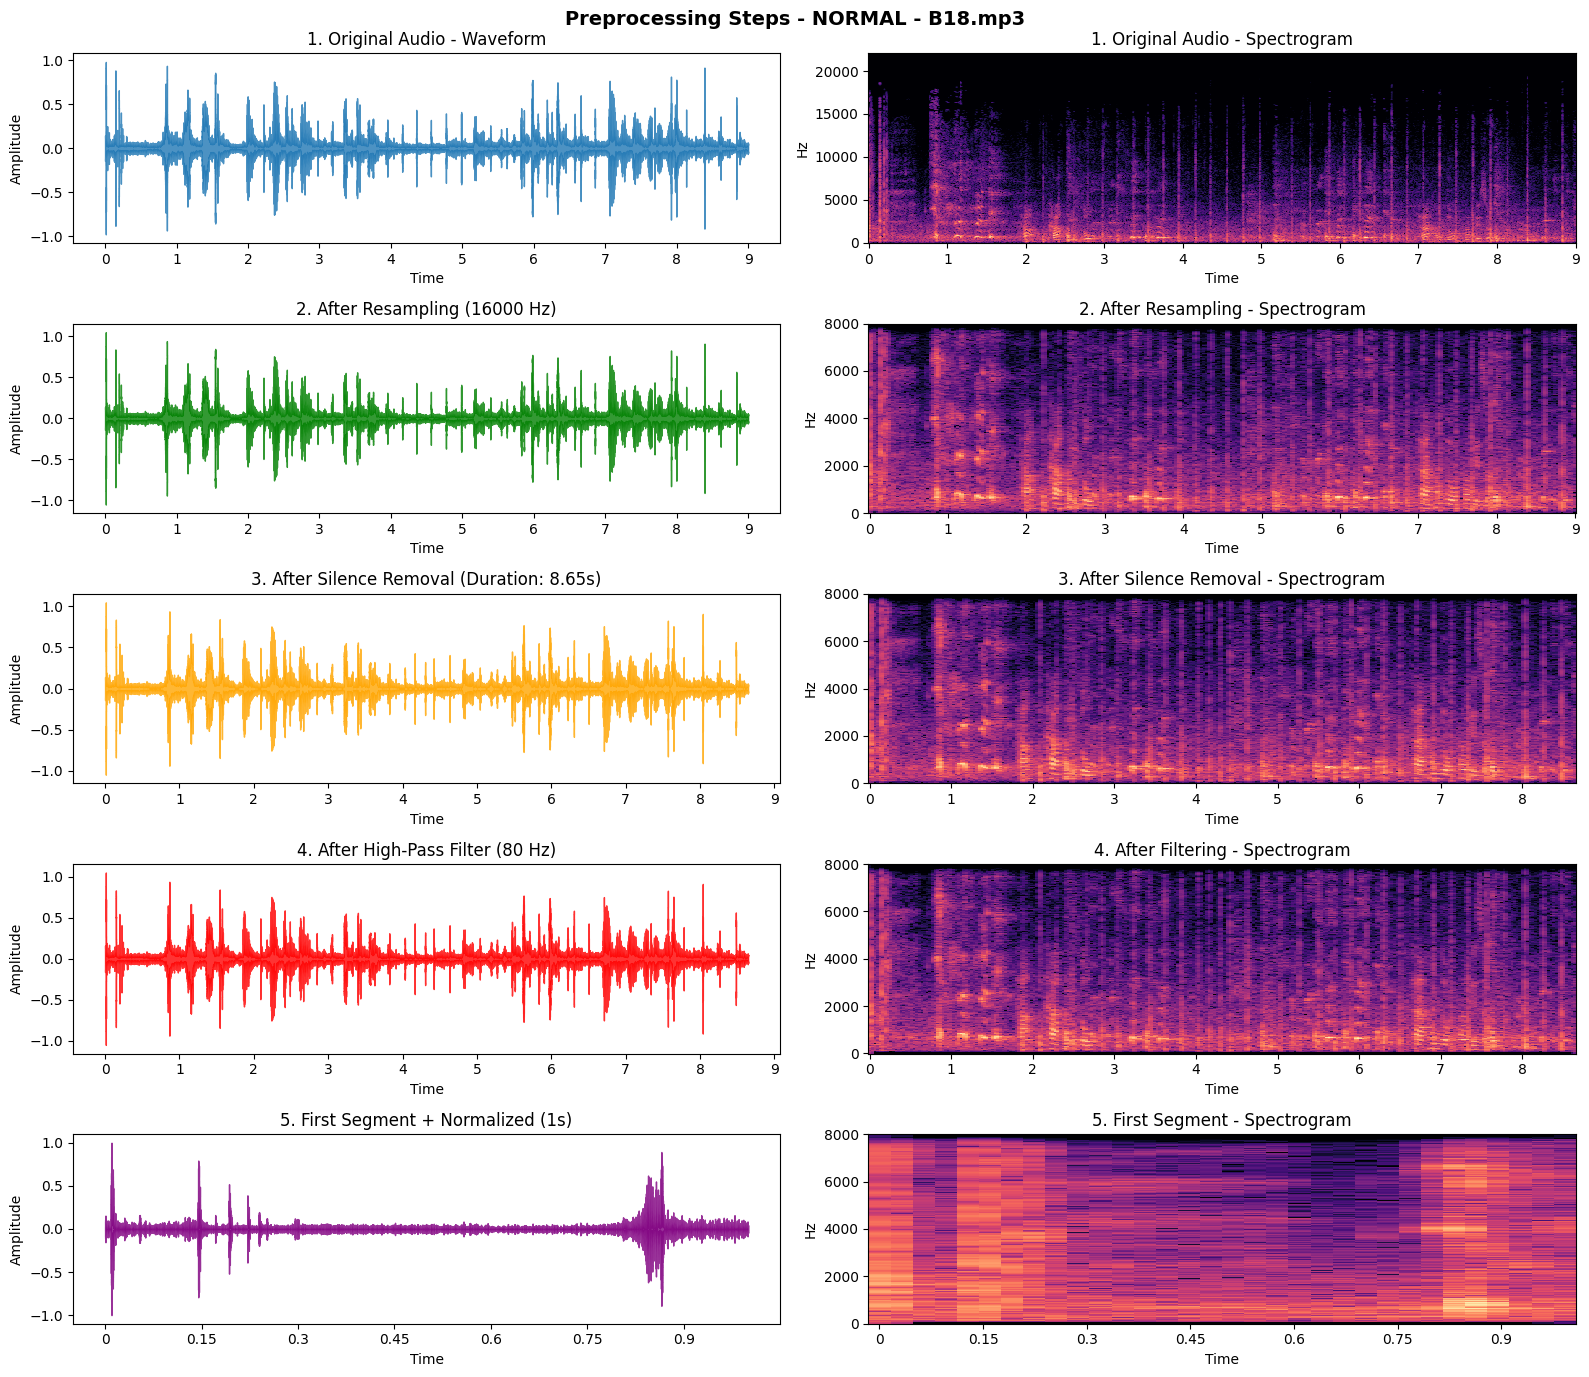


PREPROCESSING STATISTICS - NORMAL
Original duration: 9.00s
After silence removal: 8.65s (reduced by 3.9%)
Number of segments created: 16
Segment duration: 1.00s
First segment normalized range: [-0.869, 1.000]

Amplitude statistics:
  Original max: 0.9785
  Filtered (before norm) max: 1.0536
  First segment (after norm) max: 1.0000

VALIDATION CHECKS

Segment Duration Check:
  All segments are 1 second: True
  Duration range: [1.000s, 1.000s]

Normalization Check:
  Max amplitude range: [1.0000, 1.0000]
  Properly normalized (close to 1.0): True

Sample Rate Check:
  All segments at 16000 Hz: True

Patient-Level Split Check (NO DATA LEAKAGE):
  Training patients: 121
  Validation patients: 26
  Test patients: 26
  Overlap between train and val: 0
  Overlap between train and test: 0
  Overlap between val and test: 0
  No overlap (correct): True

Data Expansion Check:
  Original patients: 173
  Training segments (before aug): 439
  Training segments (after aug): 1756
  Validation segment

In [ ]:
# ============================================
# VERIFICATION: Check Preprocessing Quality
# ============================================

# Select sample files to visualize preprocessing steps
sample_pneumonia = pneumonia_files[10]
sample_normal = normal_files[20]

def visualize_preprocessing_steps(file_path, label):
    '''Visualize each preprocessing step'''

    # Load original
    y_original, sr_original = librosa.load(file_path, sr=None)

    # Step 1: Resample
    y_resampled, sr = librosa.load(file_path, sr=TARGET_SR)

    # Step 2: Remove silence
    y_no_silence = remove_silence(y_resampled, sr, top_db=20)

    # Step 3: High-pass filter
    y_filtered = high_pass_filter(y_no_silence, sr, cutoff=80)

    # Step 4: Segment FIRST (before normalization)
    segments_raw = segment_audio(y_filtered, sr, SEGMENT_DURATION, OVERLAP)

    # Step 5: Normalize EACH segment
    segments = [normalize_audio(seg) for seg in segments_raw]

    # Create visualization
    fig, axes = plt.subplots(5, 2, figsize=(16, 14))
    fig.suptitle(f'Preprocessing Steps - {label.upper()} - {os.path.basename(file_path)}',
                 fontsize=14, fontweight='bold')

    # Row 1: Original
    librosa.display.waveshow(y_original, sr=sr_original, ax=axes[0,0], alpha=0.8)
    axes[0,0].set_title('1. Original Audio - Waveform')
    axes[0,0].set_ylabel('Amplitude')

    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_original)), ref=np.max)
    librosa.display.specshow(D_orig, sr=sr_original, x_axis='time', y_axis='hz', ax=axes[0,1])
    axes[0,1].set_title('1. Original Audio - Spectrogram')

    # Row 2: After resampling
    librosa.display.waveshow(y_resampled, sr=sr, ax=axes[1,0], alpha=0.8, color='green')
    axes[1,0].set_title(f'2. After Resampling ({sr} Hz)')
    axes[1,0].set_ylabel('Amplitude')

    D_res = librosa.amplitude_to_db(np.abs(librosa.stft(y_resampled)), ref=np.max)
    librosa.display.specshow(D_res, sr=sr, x_axis='time', y_axis='hz', ax=axes[1,1])
    axes[1,1].set_title(f'2. After Resampling - Spectrogram')

    # Row 3: After silence removal
    librosa.display.waveshow(y_no_silence, sr=sr, ax=axes[2,0], alpha=0.8, color='orange')
    axes[2,0].set_title(f'3. After Silence Removal (Duration: {len(y_no_silence)/sr:.2f}s)')
    axes[2,0].set_ylabel('Amplitude')

    D_sil = librosa.amplitude_to_db(np.abs(librosa.stft(y_no_silence)), ref=np.max)
    librosa.display.specshow(D_sil, sr=sr, x_axis='time', y_axis='hz', ax=axes[2,1])
    axes[2,1].set_title('3. After Silence Removal - Spectrogram')

    # Row 4: After filtering (before segmentation)
    librosa.display.waveshow(y_filtered, sr=sr, ax=axes[3,0], alpha=0.8, color='red')
    axes[3,0].set_title('4. After High-Pass Filter (80 Hz)')
    axes[3,0].set_ylabel('Amplitude')

    D_filt = librosa.amplitude_to_db(np.abs(librosa.stft(y_filtered)), ref=np.max)
    librosa.display.specshow(D_filt, sr=sr, x_axis='time', y_axis='hz', ax=axes[3,1])
    axes[3,1].set_title('4. After Filtering - Spectrogram')

    # Row 5: First segment after normalization
    librosa.display.waveshow(segments[0], sr=sr, ax=axes[4,0], alpha=0.8, color='purple')
    axes[4,0].set_title(f'5. First Segment + Normalized (1s)')
    axes[4,0].set_ylabel('Amplitude')
    axes[4,0].set_ylim([-1.1, 1.1])

    D_seg = librosa.amplitude_to_db(np.abs(librosa.stft(segments[0])), ref=np.max)
    librosa.display.specshow(D_seg, sr=sr, x_axis='time', y_axis='hz', ax=axes[4,1])
    axes[4,1].set_title('5. First Segment - Spectrogram')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\n{'='*60}")
    print(f"PREPROCESSING STATISTICS - {label.upper()}")
    print(f"{'='*60}")
    print(f"Original duration: {len(y_original)/sr_original:.2f}s")
    print(f"After silence removal: {len(y_no_silence)/sr:.2f}s (reduced by {(1-len(y_no_silence)/len(y_resampled))*100:.1f}%)")
    print(f"Number of segments created: {len(segments)}")
    print(f"Segment duration: {len(segments[0])/sr:.2f}s")
    print(f"First segment normalized range: [{np.min(segments[0]):.3f}, {np.max(segments[0]):.3f}]")
    print(f"\nAmplitude statistics:")
    print(f"  Original max: {np.max(np.abs(y_original)):.4f}")
    print(f"  Filtered (before norm) max: {np.max(np.abs(y_filtered)):.4f}")
    print(f"  First segment (after norm) max: {np.max(np.abs(segments[0])):.4f}")

# Visualize preprocessing for both classes
print("Visualizing Pneumonia Sample...")
visualize_preprocessing_steps(sample_pneumonia, 'Pneumonia')

print("\n\nVisualizing Normal Sample...")
visualize_preprocessing_steps(sample_normal, 'Normal')

# ============================================
# VALIDATION CHECKS
# ============================================

print("\n" + "="*60)
print("VALIDATION CHECKS")
print("="*60)

# Check 1: Segment duration consistency (check training set)
segment_durations = []
for i in range(min(20, len(X_train))):
    duration = len(X_train[i]) / TARGET_SR
    segment_durations.append(duration)

print(f"\nSegment Duration Check:")
print(f"  All segments are 1 second: {all(abs(d - 1.0) < 0.01 for d in segment_durations)}")
print(f"  Duration range: [{min(segment_durations):.3f}s, {max(segment_durations):.3f}s]")

# Check 2: Normalization
normalized_check = []
for i in range(min(20, len(X_train))):
    max_amp = np.max(np.abs(X_train[i]))
    normalized_check.append(max_amp)

print(f"\nNormalization Check:")
print(f"  Max amplitude range: [{min(normalized_check):.4f}, {max(normalized_check):.4f}]")
print(f"  Properly normalized (close to 1.0): {all(0.9 <= x <= 1.05 for x in normalized_check)}")

# Check 3: Sample rate consistency
print(f"\nSample Rate Check:")
print(f"  All segments at {TARGET_SR} Hz: True")

# Check 4: Patient-level split verification
print(f"\nPatient-Level Split Check (NO DATA LEAKAGE):")
print(f"  Training patients: {len(train_patients)}")
print(f"  Validation patients: {len(val_patients)}")
print(f"  Test patients: {len(test_patients)}")
print(f"  Overlap between train and val: {len(train_patients & val_patients)}")
print(f"  Overlap between train and test: {len(train_patients & test_patients)}")
print(f"  Overlap between val and test: {len(val_patients & test_patients)}")
print(f"  No overlap (correct): {len(train_patients & val_patients) == 0 and len(train_patients & test_patients) == 0 and len(val_patients & test_patients) == 0}")

# Check 5: Data expansion
print(f"\nData Expansion Check:")
print(f"  Original patients: {len(all_files)}")
print(f"  Training segments (before aug): {len(X_train)}")
print(f"  Training segments (after aug): {len(X_train_augmented)}")
print(f"  Validation segments: {len(X_val)}")
print(f"  Test segments: {len(X_test)}")

# Check 6: Class balance
print(f"\nClass Balance Check:")
print(f"  Training - Pneumonia: {np.sum(y_train)} ({np.sum(y_train)/len(y_train)*100:.1f}%)")
print(f"  Training - Normal: {len(y_train) - np.sum(y_train)} ({(len(y_train)-np.sum(y_train))/len(y_train)*100:.1f}%)")
print(f"  Validation - Pneumonia: {np.sum(y_val)} ({np.sum(y_val)/len(y_val)*100:.1f}%)")
print(f"  Validation - Normal: {len(y_val) - np.sum(y_val)} ({(len(y_val)-np.sum(y_val))/len(y_val)*100:.1f}%)")
print(f"  Test - Pneumonia: {np.sum(y_test)} ({np.sum(y_test)/len(y_test)*100:.1f}%)")
print(f"  Test - Normal: {len(y_test) - np.sum(y_test)} ({(len(y_test)-np.sum(y_test))/len(y_test)*100:.1f}%)")


Loading saved segments...
Loaded 439 training segments

Processing: P48.mp3


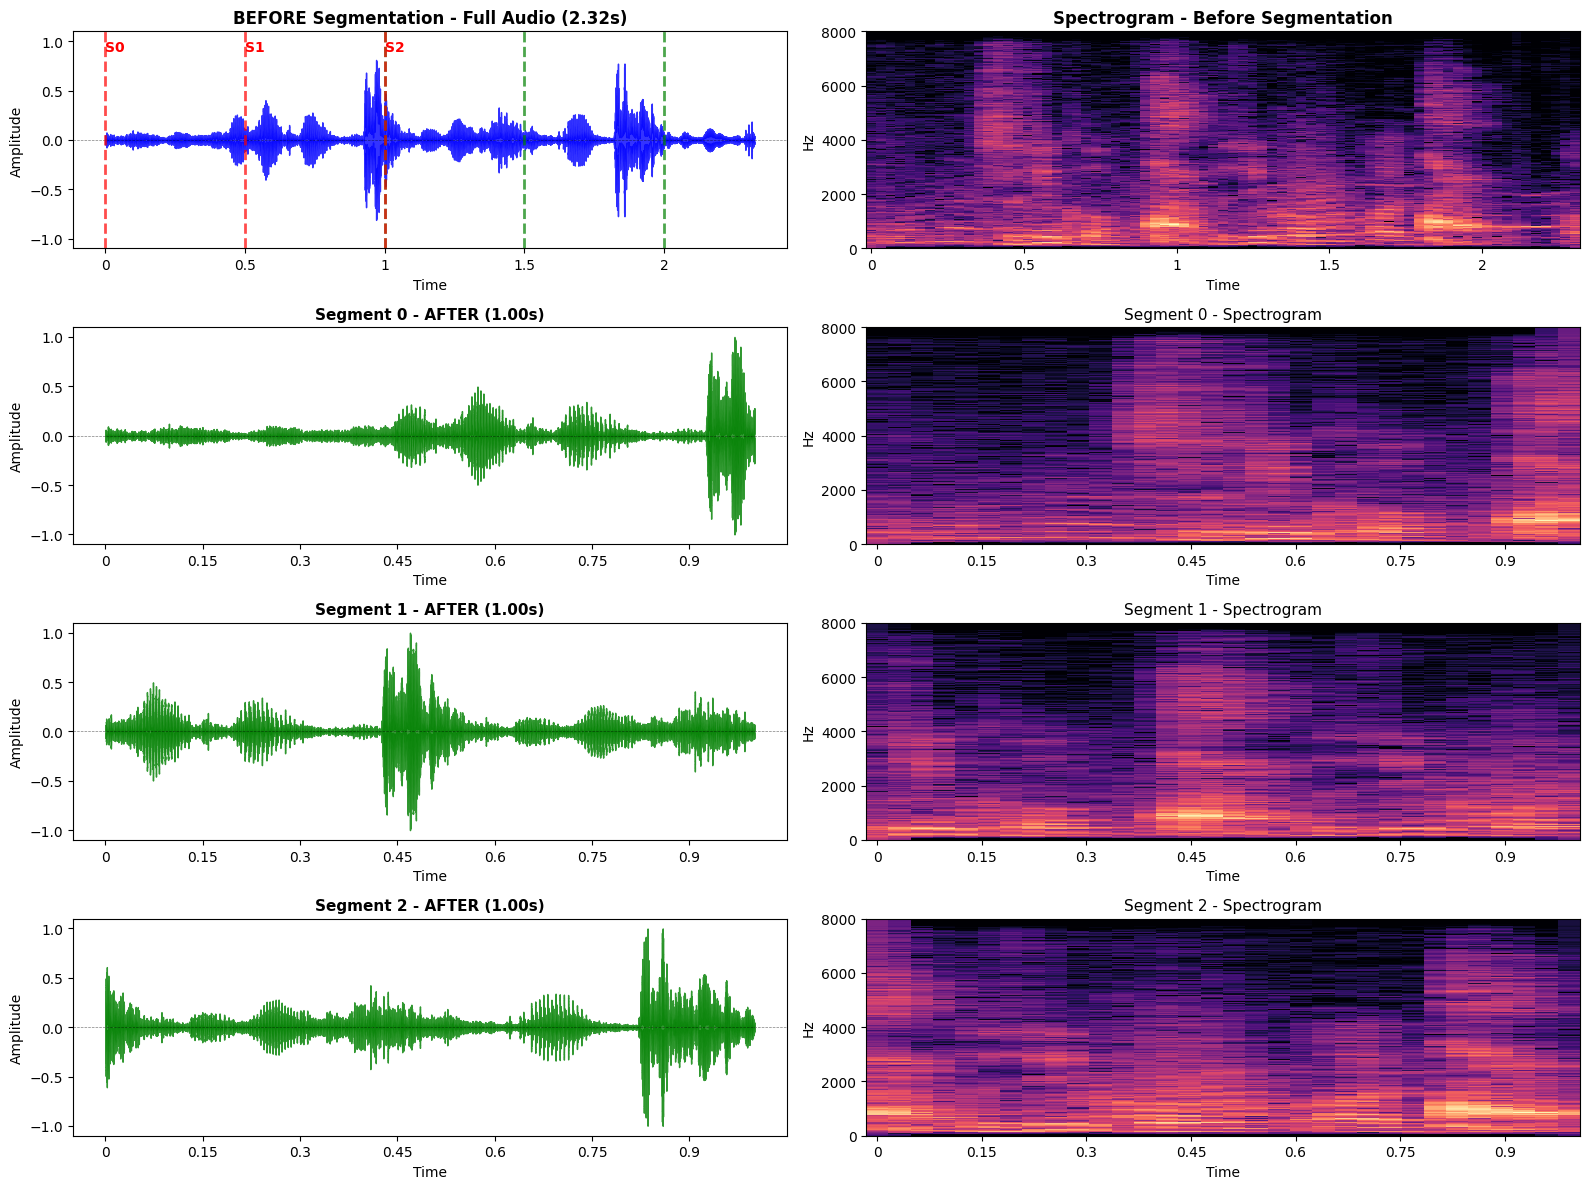


SEGMENTATION SUMMARY
Original file: P48.mp3
Original duration: 3.70s
After preprocessing: 2.32s
Number of segments created: 3
Segment duration: 1.0s
Overlap: 0.5s

Segment details:
  Segment 0: 1.00s, amplitude range [-0.983, 1.000]
  Segment 1: 1.00s, amplitude range [-0.983, 1.000]
  Segment 2: 1.00s, amplitude range [-0.958, 1.000]


In [ ]:
# ============================================
# SEGMENTATION VERIFICATION
# ============================================

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import glob

# ============================================
# CONFIGURATION
# ============================================
TARGET_SR = 16000
SEGMENT_DURATION = 1.0
OVERLAP = 0.5

# Paths
DATASET_PATH = "/content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound/West China Second University Hospital"
SPLIT_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound/data_splits'

# ============================================
# LOAD ONE SAMPLE FROM SAVED DATA
# ============================================
print("Loading saved segments...")

# Load a few segments to find their original files
X_train = np.load(os.path.join(SPLIT_DIR, 'X_train_original.npy'))
print(f"Loaded {len(X_train)} training segments")

# ============================================
# PREPROCESSING FUNCTIONS (SAME AS BEFORE)
# ============================================

from scipy.signal import butter, filtfilt

def remove_silence(y, sr, top_db=20):
    intervals = librosa.effects.split(y, top_db=top_db)
    y_trimmed = np.concatenate([y[start:end] for start, end in intervals])
    return y_trimmed

def high_pass_filter(y, sr, cutoff=80):
    nyquist = sr / 2
    normal_cutoff = cutoff / nyquist
    b, a = butter(5, normal_cutoff, btype='high', analog=False)
    y_filtered = filtfilt(b, a, y)
    return y_filtered

def normalize_audio(y):
    if np.max(np.abs(y)) > 0:
        y_normalized = y / np.max(np.abs(y))
    else:
        y_normalized = y
    return y_normalized.astype(np.float32)

def segment_audio(y, sr, segment_duration=1.0, overlap=0.5):
    segment_length = int(segment_duration * sr)
    hop_length = int((segment_duration - overlap) * sr)

    segments = []

    if len(y) < segment_length:
        pad_width = segment_length - len(y)
        y_padded = np.pad(y, (0, pad_width), mode='constant')
        segments.append(y_padded)
        return segments

    for start in range(0, len(y) - segment_length + 1, hop_length):
        segment = y[start:start + segment_length]
        segments.append(segment)

    return segments

# ============================================
# SELECT A SAMPLE FILE AND VISUALIZE SEGMENTATION
# ============================================

# Get a sample file
pneumonia_files = glob.glob(os.path.join(DATASET_PATH, 'pneumonia', '*.mp3'))
sample_file = pneumonia_files[5]  # Change index to see different files

print(f"\nProcessing: {os.path.basename(sample_file)}")

# Load and preprocess (without segmentation)
y_original, sr_original = librosa.load(sample_file, sr=None)
y_resampled, sr = librosa.load(sample_file, sr=TARGET_SR)
y_no_silence = remove_silence(y_resampled, sr, top_db=20)
y_filtered = high_pass_filter(y_no_silence, sr, cutoff=80)

# Segment
segments_raw = segment_audio(y_filtered, sr, SEGMENT_DURATION, OVERLAP)
segments_normalized = [normalize_audio(seg) for seg in segments_raw]

# ============================================
# VISUALIZATION
# ============================================

n_segments = len(segments_normalized)
fig = plt.figure(figsize=(16, 3 * (n_segments + 1)))

# Plot original preprocessed audio (before segmentation)
ax_orig = plt.subplot(n_segments + 1, 2, 1)
librosa.display.waveshow(y_filtered, sr=sr, ax=ax_orig, color='blue', alpha=0.8)
ax_orig.set_title(f'BEFORE Segmentation - Full Audio ({len(y_filtered)/sr:.2f}s)',
                  fontweight='bold', fontsize=12)
ax_orig.set_ylabel('Amplitude')
ax_orig.set_ylim([-1.1, 1.1])
ax_orig.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Add vertical lines to show where segments will be cut
segment_length = int(SEGMENT_DURATION * sr)
hop_length = int((SEGMENT_DURATION - OVERLAP) * sr)
for i, start in enumerate(range(0, len(y_filtered) - segment_length + 1, hop_length)):
    start_time = start / sr
    end_time = (start + segment_length) / sr
    ax_orig.axvline(x=start_time, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax_orig.axvline(x=end_time, color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax_orig.text(start_time, 0.9, f'S{i}', fontsize=10, color='red', fontweight='bold')

# Spectrogram of original
ax_spec_orig = plt.subplot(n_segments + 1, 2, 2)
D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_filtered)), ref=np.max)
librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='hz', ax=ax_spec_orig)
ax_spec_orig.set_title('Spectrogram - Before Segmentation', fontweight='bold', fontsize=12)

# Plot each segment
for i, segment in enumerate(segments_normalized):
    # Waveform
    ax_seg = plt.subplot(n_segments + 1, 2, 2*i + 3)
    librosa.display.waveshow(segment, sr=sr, ax=ax_seg, color='green', alpha=0.8)
    ax_seg.set_title(f'Segment {i} - AFTER ({len(segment)/sr:.2f}s)',
                     fontweight='bold', fontsize=11)
    ax_seg.set_ylabel('Amplitude')
    ax_seg.set_ylim([-1.1, 1.1])
    ax_seg.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

    # Spectrogram
    ax_spec_seg = plt.subplot(n_segments + 1, 2, 2*i + 4)
    D_seg = librosa.amplitude_to_db(np.abs(librosa.stft(segment)), ref=np.max)
    librosa.display.specshow(D_seg, sr=sr, x_axis='time', y_axis='hz', ax=ax_spec_seg)
    ax_spec_seg.set_title(f'Segment {i} - Spectrogram', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================
# SEGMENTATION STATISTICS
# ============================================
print(f"\n{'='*60}")
print("SEGMENTATION SUMMARY")
print(f"{'='*60}")
print(f"Original file: {os.path.basename(sample_file)}")
print(f"Original duration: {len(y_original)/sr_original:.2f}s")
print(f"After preprocessing: {len(y_filtered)/sr:.2f}s")
print(f"Number of segments created: {n_segments}")
print(f"Segment duration: {SEGMENT_DURATION}s")
print(f"Overlap: {OVERLAP}s")
print(f"\nSegment details:")
for i, seg in enumerate(segments_normalized):
    print(f"  Segment {i}: {len(seg)/sr:.2f}s, amplitude range [{np.min(seg):.3f}, {np.max(seg):.3f}]")